# Data Science - Atrial Fibrillation

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, recall_score, f1_score
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt

import seaborn as sns

In [2]:
df = pd.read_excel("data/Preprocessed_AFData.xlsx")

In [3]:
df.head()

,data1,data2,data3,data4,data5,data6,data7,data8,data9,data10,...,data22,data23,data24,data25,data26,data27,data28,data29,data30,Control
0,0.0,0.0,0.0,0.1,-0.1,0.0,0.0,0.4,0.100000,0.500000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,0.0,0.0,0.0,0.0,0.0,1.0,-0.4,-0.6,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.954545,0.045455,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


## Split To Train And Test

In [4]:
df_pos = df[df["Control"] == 1]
df_neg = df[df["Control"] == 0]

n_samples_per_class = min(len(df_pos), len(df_neg), 15000)

df_train_pos = df_pos.sample(n=n_samples_per_class, random_state=42)
df_train_neg = df_neg.sample(n=n_samples_per_class, random_state=42)
df_train = pd.concat([df_train_pos, df_train_neg]).sample(frac=1, random_state=42)

df_test = df.drop(df_train.index)

X_train = df_train.drop(columns=["Control"])
y_train = df_train["Control"]

X_test = df_test.drop(columns=["Control"])
y_test = df_test["Control"]

In [5]:
print(f"X train size: {X_train.shape} with y size: {y_train.shape}")
print("y_train class distribution:")
print(y_train.value_counts())

print(f"\nX test size: {X_test.shape} with y size: {y_test.shape}")
print("y_test class distribution:")
print(y_test.value_counts())

X train size: (30000, 30) with y size: (30000,)
y_train class distribution:
Control
1    15000
0    15000
Name: count, dtype: int64

X test size: (120000, 30) with y size: (120000,)
y_test class distribution:
Control
0    98463
1    21537
Name: count, dtype: int64


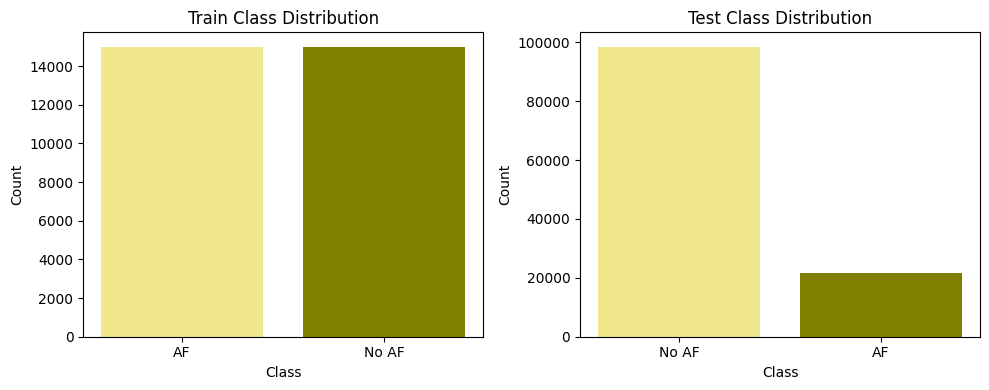

In [6]:
y_train_named = y_train.replace({0: 'No AF', 1: 'AF'})
y_test_named = y_test.replace({0: 'No AF', 1: 'AF'})

train_counts = y_train_named.value_counts()
test_counts = y_test_named.value_counts()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(train_counts.index, train_counts.values, color=['khaki', 'olive'])
axes[0].set_title('Train Class Distribution')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')

axes[1].bar(test_counts.index, test_counts.values, color=['khaki', 'olive'])
axes[1].set_title('Test Class Distribution')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## Model Options

In [7]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": LinearSVC(max_iter=5000),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

## Helper Functions

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


def evaluate_model_cv(model_name, model):
    print(f"\n=== Cross-Validation Estimate: {model_name} ===")
    all_y_true = []
    all_y_pred = []

    pipe = Pipeline([
        ('classifier', model)
    ])

    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        pipe.fit(X_tr, y_tr)
        y_pred = pipe.predict(X_val)

        all_y_true.extend(y_val)
        all_y_pred.extend(y_pred)

    print("\nCV Classification Report (Validation Performance):")
    print(classification_report(all_y_true, all_y_pred, digits=3))

def evaluate_model_test(model_name, model):
    print(f"\n=== Final Test Evaluation: {model_name} ===")

    pipe = Pipeline([
        # ('scaler', StandardScaler()),
        ('pca', PCA(n_components=0.99)),
        ('classifier', model)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    print(classification_report(y_test, y_pred, digits=3))

    macro_recall = recall_score(y_test, y_pred, average='macro')
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    print(f"Macro Recall: {macro_recall:.3f}")
    print(f"Macro F1: {macro_f1:.3f}")

    labels=[0, 1]
    class_names=['No AF', 'AF']
    cm = confusion_matrix(y_test, y_pred, labels=labels)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix: {model_name}")
    plt.tight_layout()
    plt.show()

    try:
        pca_model = pipe.named_steps["pca"]
        retained_components = pca_model.n_components_
        feature_contributions = np.abs(pca_model.components_).sum(axis=0)
        sorted_indices = np.argsort(feature_contributions)[::-1]

        retained_feature_names = X_train.columns[sorted_indices[:retained_components]]
        dropped_features = X_train.columns.difference(retained_feature_names)

        print(f"\nPCA retained {retained_components} components out of {X_train.shape[1]} features.")
        print(f"Dropped features by PCA:\n{list(dropped_features)}")

        model_fitted = pipe.named_steps["classifier"]
        if hasattr(model_fitted, "feature_importances_"):
            importances = model_fitted.feature_importances_
        elif hasattr(model_fitted, "coef_"):
            importances = np.abs(model_fitted.coef_[0])
        else:
            raise AttributeError("Model does not support feature importances.")

        feature_importance_df = pd.DataFrame({
            "Feature": retained_feature_names[:len(importances)],
            "Importance": importances
        }).sort_values(by="Importance", ascending=False)

        print("\nTop 10 Most Important Features (after PCA):")
        top_features = feature_importance_df.sort_values(by="Importance", ascending=False)

        plt.figure(figsize=(10, 6))
        bars = plt.bar(top_features['Feature'], top_features['Importance'], color='skyblue')
        plt.ylabel("Importance")
        plt.title(f"Feature Importances: {model_name}")
        plt.xticks(rotation=45, ha='right') 
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"\n[!] Could not extract feature importances or PCA details: {e}")

    return {"Model": model_name, "Macro Recall": macro_recall, "Macro F1": macro_f1}

## Train + Test Models


=== Cross-Validation Estimate: Logistic Regression ===

CV Classification Report (Validation Performance):
              precision    recall  f1-score   support

           0      0.893     0.962     0.926     15000
           1      0.959     0.884     0.920     15000

    accuracy                          0.923     30000
   macro avg      0.926     0.923     0.923     30000
weighted avg      0.926     0.923     0.923     30000


=== Final Test Evaluation: Logistic Regression ===
              precision    recall  f1-score   support

           0      0.966     0.959     0.962     98463
           1      0.817     0.847     0.832     21537

    accuracy                          0.939    120000
   macro avg      0.892     0.903     0.897    120000
weighted avg      0.940     0.939     0.939    120000

Macro Recall: 0.903
Macro F1: 0.897


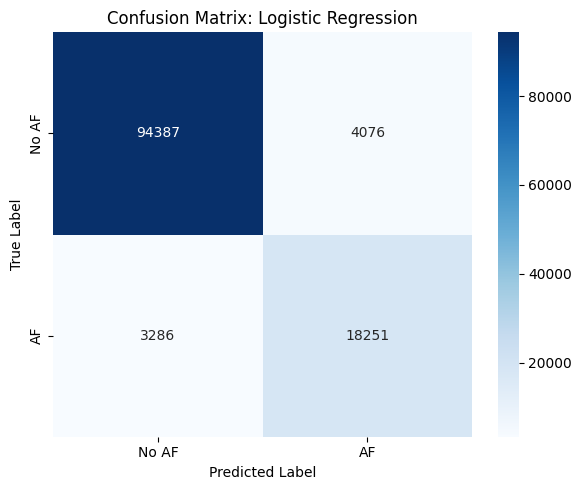


PCA retained 15 components out of 30 features.
Dropped features by PCA:
['data1', 'data17', 'data18', 'data19', 'data20', 'data21', 'data22', 'data23', 'data24', 'data25', 'data26', 'data27', 'data28', 'data29', 'data30']

Top 10 Most Important Features (after PCA):


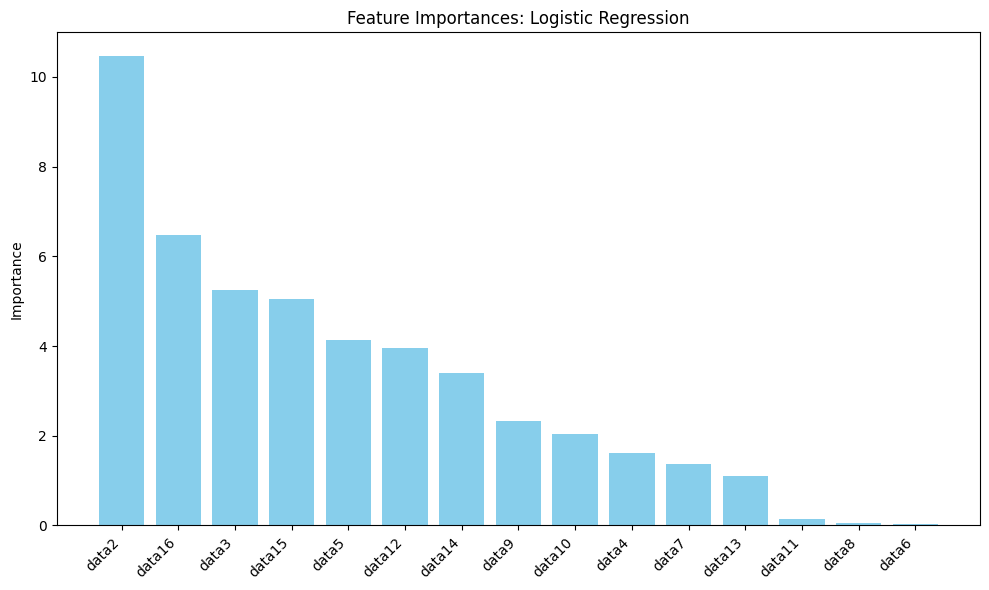


=== Cross-Validation Estimate: Decision Tree ===

CV Classification Report (Validation Performance):
              precision    recall  f1-score   support

           0      0.909     0.946     0.927     15000
           1      0.943     0.905     0.924     15000

    accuracy                          0.925     30000
   macro avg      0.926     0.925     0.925     30000
weighted avg      0.926     0.925     0.925     30000


=== Final Test Evaluation: Decision Tree ===
              precision    recall  f1-score   support

           0      0.977     0.946     0.961     98463
           1      0.785     0.900     0.839     21537

    accuracy                          0.938    120000
   macro avg      0.881     0.923     0.900    120000
weighted avg      0.943     0.938     0.939    120000

Macro Recall: 0.923
Macro F1: 0.900


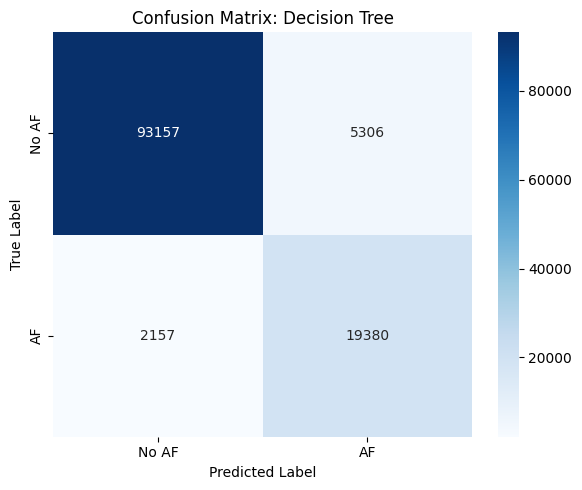


PCA retained 15 components out of 30 features.
Dropped features by PCA:
['data1', 'data17', 'data18', 'data19', 'data20', 'data21', 'data22', 'data23', 'data24', 'data25', 'data26', 'data27', 'data28', 'data29', 'data30']

Top 10 Most Important Features (after PCA):


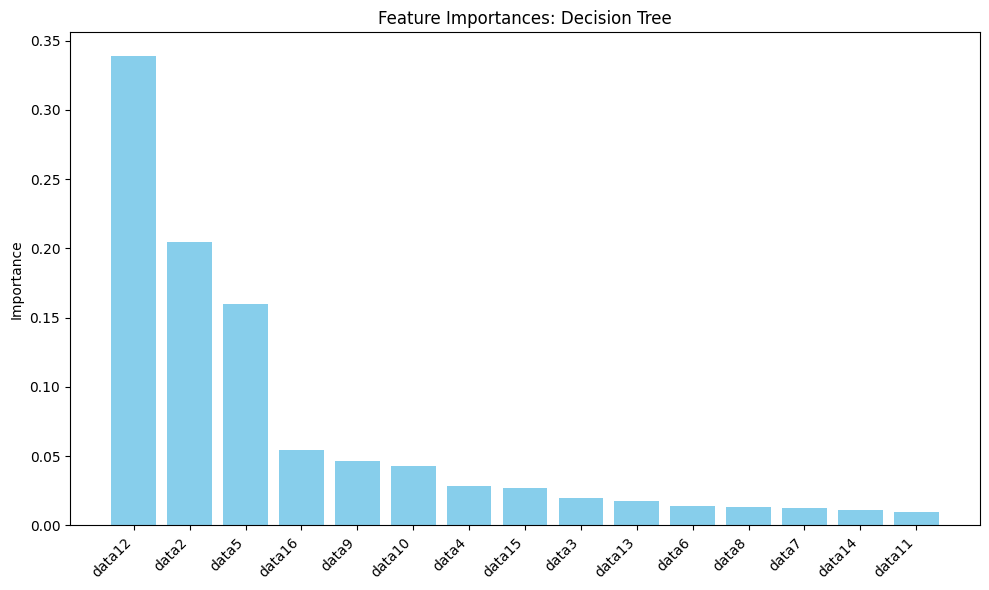


=== Cross-Validation Estimate: Random Forest ===

CV Classification Report (Validation Performance):
              precision    recall  f1-score   support

           0      0.945     0.956     0.950     15000
           1      0.956     0.944     0.950     15000

    accuracy                          0.950     30000
   macro avg      0.950     0.950     0.950     30000
weighted avg      0.950     0.950     0.950     30000


=== Final Test Evaluation: Random Forest ===
              precision    recall  f1-score   support

           0      0.987     0.959     0.973     98463
           1      0.835     0.943     0.885     21537

    accuracy                          0.956    120000
   macro avg      0.911     0.951     0.929    120000
weighted avg      0.960     0.956     0.957    120000

Macro Recall: 0.951
Macro F1: 0.929


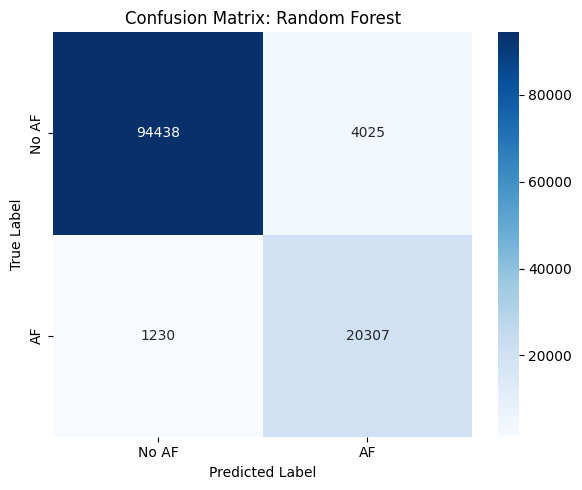


PCA retained 15 components out of 30 features.
Dropped features by PCA:
['data1', 'data17', 'data18', 'data19', 'data20', 'data21', 'data22', 'data23', 'data24', 'data25', 'data26', 'data27', 'data28', 'data29', 'data30']

Top 10 Most Important Features (after PCA):


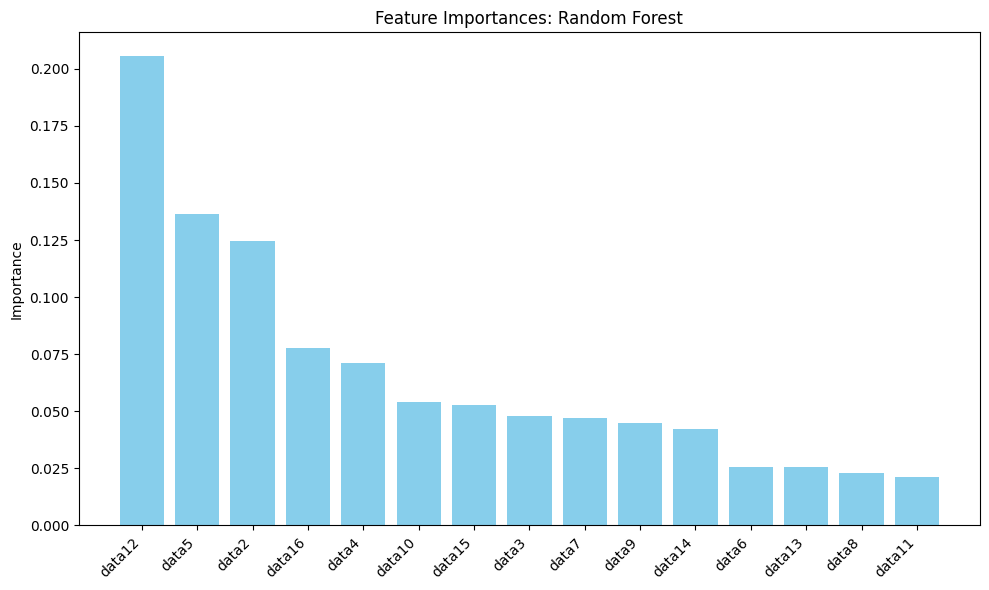


=== Cross-Validation Estimate: SVM ===

CV Classification Report (Validation Performance):
              precision    recall  f1-score   support

           0      0.892     0.962     0.926     15000
           1      0.959     0.883     0.920     15000

    accuracy                          0.923     30000
   macro avg      0.925     0.923     0.923     30000
weighted avg      0.925     0.923     0.923     30000


=== Final Test Evaluation: SVM ===
              precision    recall  f1-score   support

           0      0.964     0.960     0.962     98463
           1      0.821     0.837     0.829     21537

    accuracy                          0.938    120000
   macro avg      0.893     0.899     0.896    120000
weighted avg      0.939     0.938     0.938    120000

Macro Recall: 0.899
Macro F1: 0.896


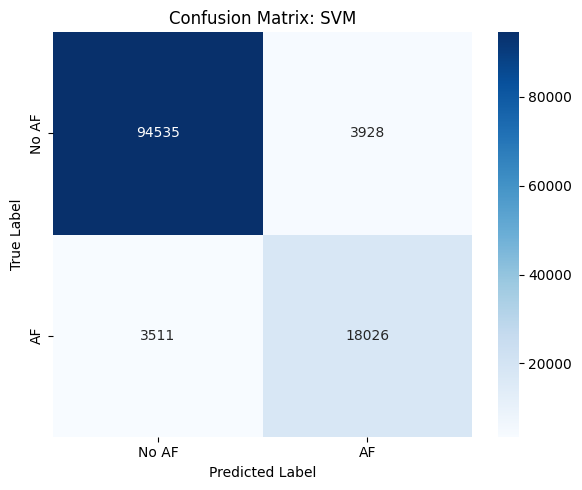


PCA retained 15 components out of 30 features.
Dropped features by PCA:
['data1', 'data17', 'data18', 'data19', 'data20', 'data21', 'data22', 'data23', 'data24', 'data25', 'data26', 'data27', 'data28', 'data29', 'data30']

Top 10 Most Important Features (after PCA):


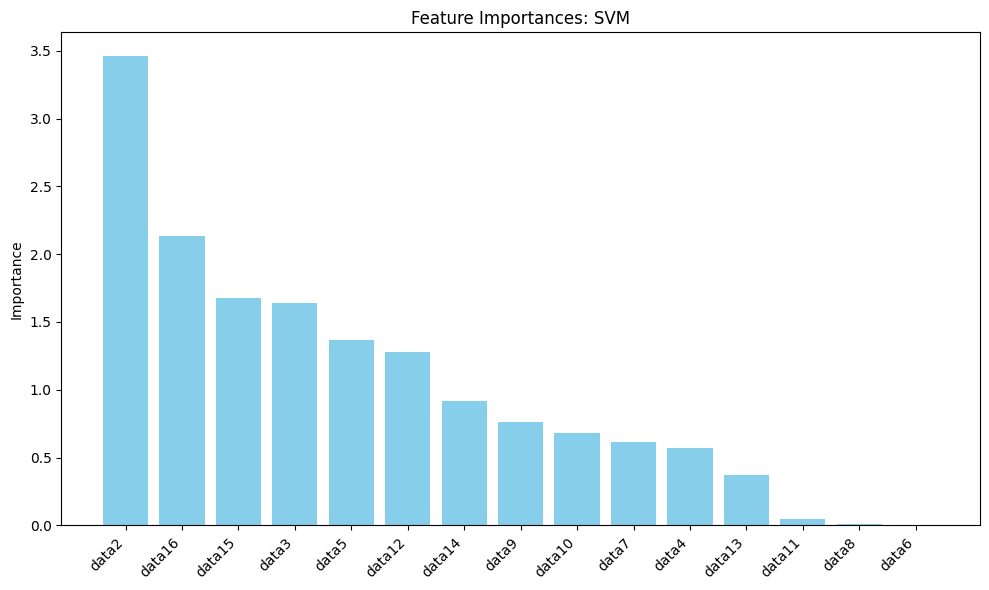


=== Cross-Validation Estimate: Naive Bayes ===

CV Classification Report (Validation Performance):
              precision    recall  f1-score   support

           0      0.884     0.587     0.706     15000
           1      0.691     0.923     0.790     15000

    accuracy                          0.755     30000
   macro avg      0.787     0.755     0.748     30000
weighted avg      0.787     0.755     0.748     30000


=== Final Test Evaluation: Naive Bayes ===
              precision    recall  f1-score   support

           0      0.965     0.927     0.946     98463
           1      0.718     0.846     0.777     21537

    accuracy                          0.913    120000
   macro avg      0.842     0.887     0.861    120000
weighted avg      0.921     0.913     0.916    120000

Macro Recall: 0.887
Macro F1: 0.861


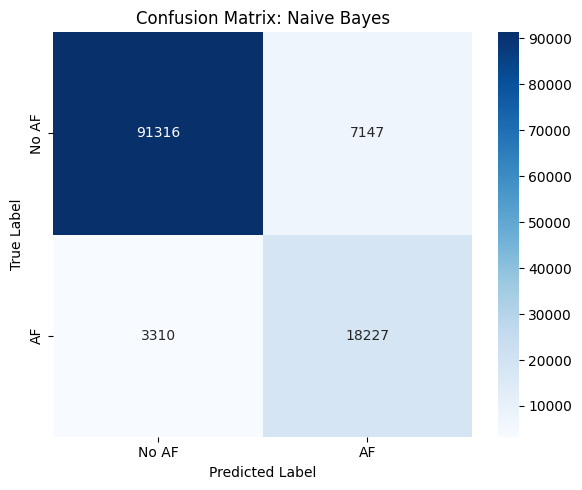


PCA retained 15 components out of 30 features.
Dropped features by PCA:
['data1', 'data17', 'data18', 'data19', 'data20', 'data21', 'data22', 'data23', 'data24', 'data25', 'data26', 'data27', 'data28', 'data29', 'data30']

[!] Could not extract feature importances or PCA details: Model does not support feature importances.

=== Cross-Validation Estimate: KNN ===

CV Classification Report (Validation Performance):
              precision    recall  f1-score   support

           0      0.931     0.957     0.944     15000
           1      0.956     0.930     0.943     15000

    accuracy                          0.943     30000
   macro avg      0.944     0.943     0.943     30000
weighted avg      0.944     0.943     0.943     30000


=== Final Test Evaluation: KNN ===
              precision    recall  f1-score   support

           0      0.985     0.958     0.971     98463
           1      0.830     0.934     0.879     21537

    accuracy                          0.954    120000
 

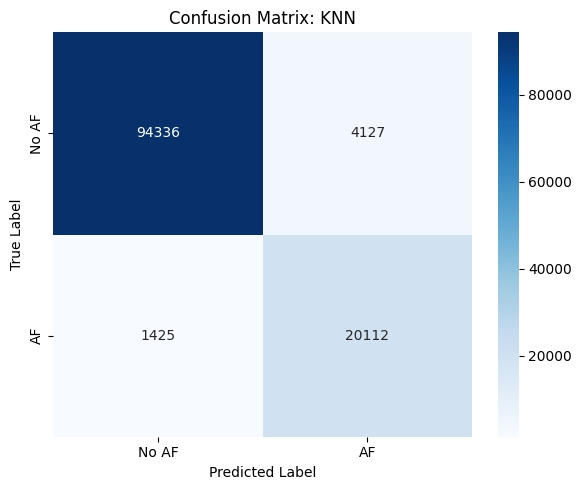


PCA retained 15 components out of 30 features.
Dropped features by PCA:
['data1', 'data17', 'data18', 'data19', 'data20', 'data21', 'data22', 'data23', 'data24', 'data25', 'data26', 'data27', 'data28', 'data29', 'data30']

[!] Could not extract feature importances or PCA details: Model does not support feature importances.

=== Cross-Validation Estimate: XGBoost ===


C:\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:20:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:20:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:20:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:20:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Python311\Lib\sit


CV Classification Report (Validation Performance):
              precision    recall  f1-score   support

           0      0.941     0.960     0.950     15000
           1      0.959     0.939     0.949     15000

    accuracy                          0.950     30000
   macro avg      0.950     0.950     0.950     30000
weighted avg      0.950     0.950     0.950     30000


=== Final Test Evaluation: XGBoost ===


C:\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:20:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0      0.987     0.962     0.974     98463
           1      0.844     0.941     0.890     21537

    accuracy                          0.958    120000
   macro avg      0.915     0.952     0.932    120000
weighted avg      0.961     0.958     0.959    120000

Macro Recall: 0.952
Macro F1: 0.932


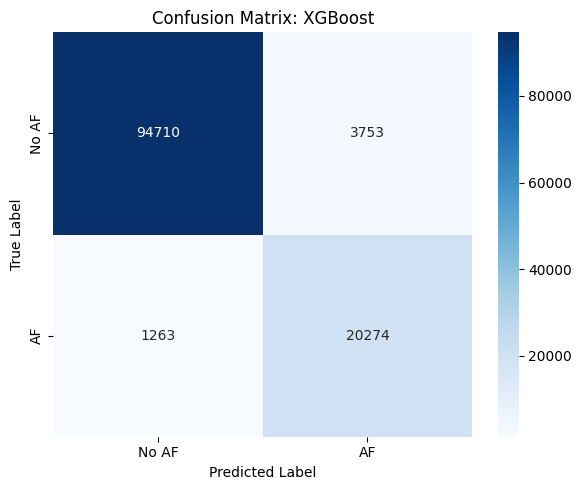


PCA retained 15 components out of 30 features.
Dropped features by PCA:
['data1', 'data17', 'data18', 'data19', 'data20', 'data21', 'data22', 'data23', 'data24', 'data25', 'data26', 'data27', 'data28', 'data29', 'data30']

Top 10 Most Important Features (after PCA):


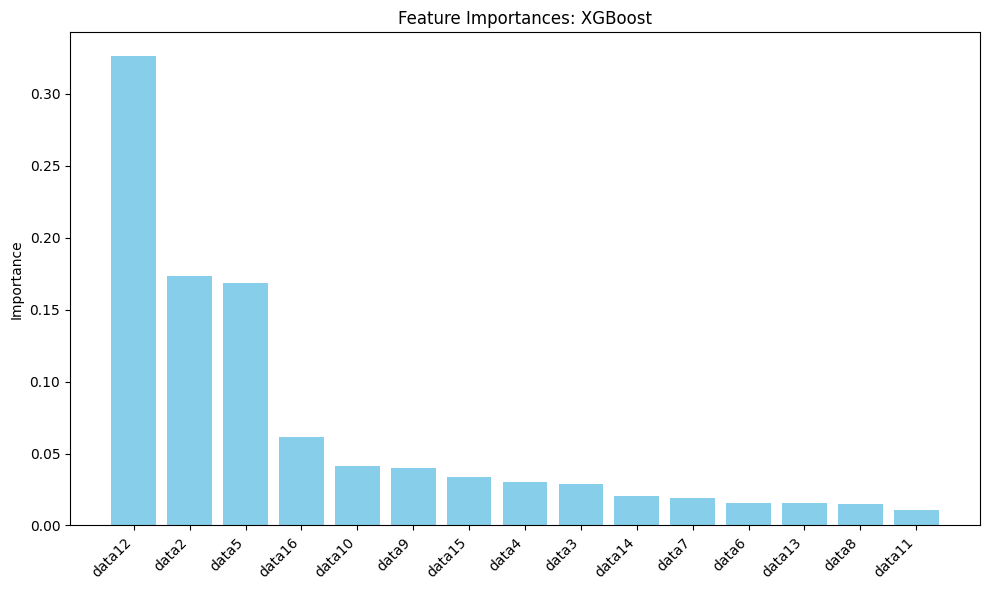

In [9]:
results = []
for name, model in models.items():
    evaluate_model_cv(name, model)
    metrics = evaluate_model_test(name, model)
    results.append(metrics)

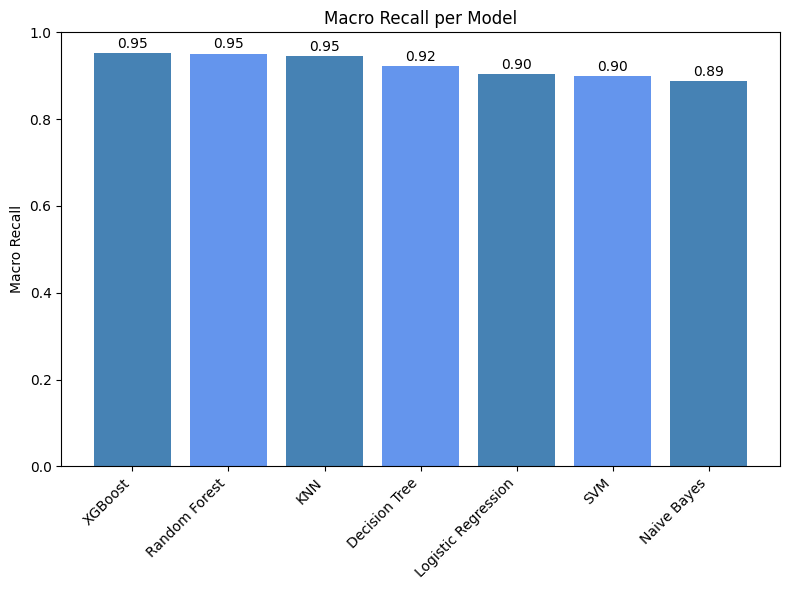

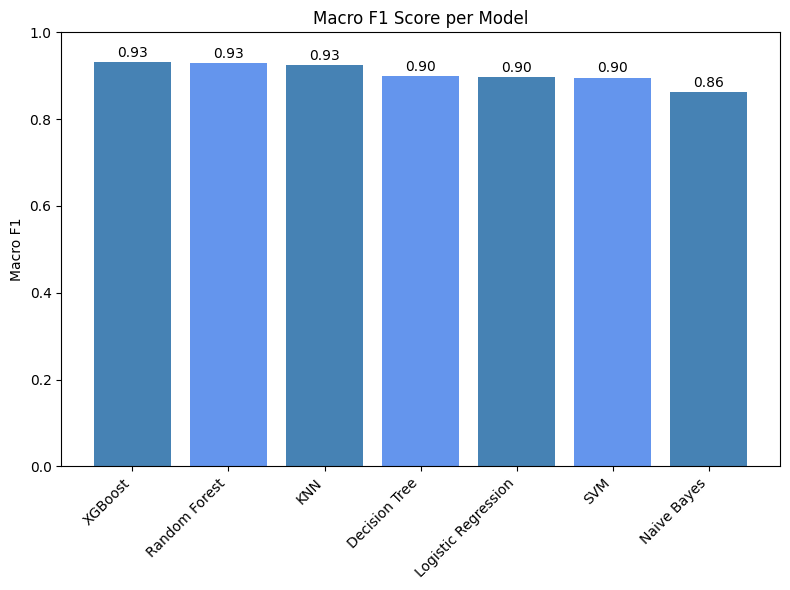

In [11]:
results_df = pd.DataFrame(results)

sorted_recall = results_df.sort_values(by="Macro Recall", ascending=False)

plt.figure(figsize=(8, 6))
bars = plt.bar(sorted_recall["Model"], sorted_recall["Macro Recall"], color=['steelblue', 'cornflowerblue'])
plt.title("Macro Recall per Model")
plt.ylabel("Macro Recall")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.005, f"{height:.2f}",
             ha='center', va='bottom')
plt.tight_layout()
plt.show()

sorted_f1 = results_df.sort_values(by="Macro F1", ascending=False)

plt.figure(figsize=(8, 6))
bars = plt.bar(sorted_f1["Model"], sorted_f1["Macro F1"], color=['steelblue', 'cornflowerblue'])
plt.title("Macro F1 Score per Model")
plt.ylabel("Macro F1")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.005, f"{height:.2f}",
             ha='center', va='bottom')
plt.tight_layout()
plt.show()